## Read the Data

In [1]:
# !pip install numpy
# !pip install matplotlib
# !pip install seaborn
# !pip install pandas
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Suppress common warnings for cleaner notebook output
import warnings

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning)
pd.options.mode.chained_assignment = None

In [2]:

saved_df = "data/dpu_results_choices.csv"
choice_results = pd.read_csv(saved_df)

user_results_path = 'data/dpu_results_users.csv'
user_results = pd.read_csv(user_results_path)


raw_choice_results = pd.read_csv("data/results_choices.csv")


In [9]:
user_results.columns

Index(['user_id', 'group', 'trust_the_agent', 'number_of_choices',
       'number_of_accepts', 'number_of_correct_choices_mean',
       'number_of_correct_choices_feedback', 'final_agent_mean_score',
       'final_agent_name', 'final_agent_rank', 'final_agent_final_part_score',
       'age', 'gender', 'education', 'familiar_with_AI',
       'evaluate_final_agent', 'ES_understandable', 'ES_overwhelming',
       'ES_feedback_contribution', 'ES_helpful', 'ES_combined'],
      dtype='object')

In [7]:
choice_results.columns

Index(['user_id', 'episode', 'group', 'trust_the_agent', 'prev_agent',
       'updated_agent', 'prev_agent_mean_score', 'update_agent_mean_score',
       'prev_agent_feedback_score', 'updated_agent_feedback_score',
       'choice_to_update', 'correct_choice_generalized',
       'correct_choice_feedback', 'choice_time', 'improved_from_prev_feedback',
       'improved_from_prev_mean'],
      dtype='object')

In [8]:
user_results['group'].value_counts()

group
Random              76
Salient-Contrast    73
Control             69
Same                62
Name: count, dtype: int64

In [9]:
choice_results = choice_results[choice_results['choice_time'] < 100]

# Start Ploting

### Ploting Methods

In [5]:
colors_palette = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6'] 
group_names = ['Control', 'Random', 'Same', 'Salient-Contrast']


# Configure matplotlib for Jupyter notebook - use inline backend
%matplotlib inline
def plot_barplot(
    df, 
    x_col, 
    y_col, 
    hue=None, 
    hue_names=None,
    x_val_names=None, 
    figsize=(8, 6), 
    estimator=lambda x: np.mean(x) * 100, 
    errorbar=('ci', 95),
    palette=None,
    x_label='Group', 
    y_label='Correct Choice %',
    order=None,
    bar_label_fmt='%.1f%%',
    ylim_bottom=0,
    save_path=None,
):
    """
    Plots a grouped barplot with annotated counts for each bar.

    Parameters:
        df (pd.DataFrame): DataFrame to plot.
        x_col (str): Column for x-axis.
        y_col (str): Column for y-axis (should be numeric/binary for mean).
        hue (str, optional): Column for grouping bars. Default: None.
        x_val_names (list, optional): Custom x-tick labels.
        figsize (tuple): Figure size.
        estimator (callable): Function to aggregate y_col (default: mean*100).
        errorbar (str): Error bar type for seaborn.
        palette (list, optional): Colors for bars.
        x_label (str, optional): X-axis label.
        y_label (str, optional): Y-axis label.
    """
    if order is None:
        order = sorted(list(df[x_col].unique()))

    plt.figure(figsize=figsize)
    ax = sns.barplot(
        data=df,
        x=x_col,
        y=y_col,
        hue=hue,
        estimator=estimator,
        errorbar=errorbar,
        palette=palette,
        order=order
    )

    for container in ax.containers:
        ax.bar_label(container, fmt=bar_label_fmt, label_type='edge', fontsize=13)#, fontweight='bold')

    if not x_val_names:
        x_val_names = sorted([str(level) for level in order])
    if len(x_val_names[0]) > 15:
        ax.set_xticklabels(x_val_names, rotation=40, ha='right', fontsize=13)
    else:
        ax.set_xticklabels(x_val_names, fontsize=13)
    if x_label:
        plt.xlabel(x_label, fontsize=14)
    if y_label:
        plt.ylabel(y_label, fontsize=14)
    plt.yticks(fontsize=13)

    handles, labels = ax.get_legend_handles_labels()
    if hue:
        if not hue_names:
            hue_names = sorted(list(df[hue].unique()))
        
        if isinstance(hue_names, dict):
            display_labels = [hue_names.get(lbl, lbl) for lbl in labels]
        else:
            display_labels = hue_names
        
        ax.legend(handles=handles, labels=display_labels, fontsize=13)
    plt.ylim(bottom=ylim_bottom)
    plt.show()




In [6]:
from scipy.stats import mannwhitneyu
import itertools

def mannwhitneyu_test(df, y_col, x_col, test_type='two-sided'):
    # Prepare data
    levels = sorted(df[x_col].unique())
    results = []

    for lvl1, lvl2 in itertools.combinations(levels, 2):
        group1 = df[df[x_col] == lvl1][y_col]
        group2 = df[df[x_col] == lvl2][y_col]
        stat, p = mannwhitneyu(group1, group2, alternative=test_type)
        results.append({'level_1': lvl1, 'level_2': lvl2, 'U': stat, 'p_value': p})

    # Convert results to DataFrame for easy viewing
    mannwhitney_results_df = pd.DataFrame(results)
    print(mannwhitney_results_df)



## Ploting

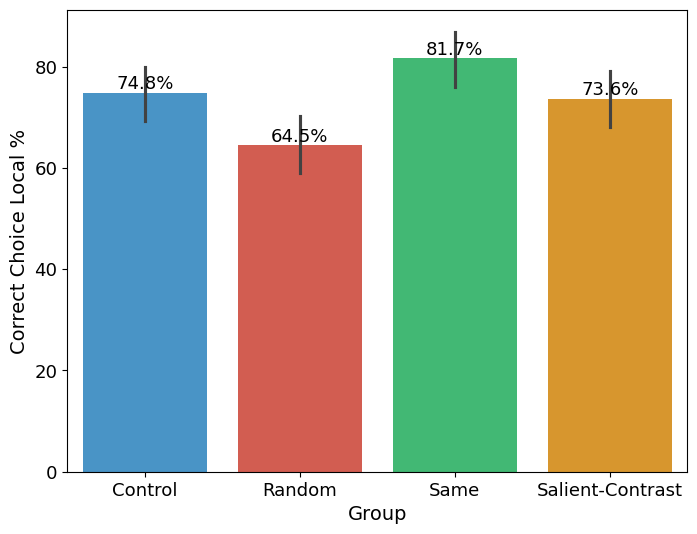

            level_1           level_2        U   p_value
0           Control            Random  33047.0  0.013284
1           Control  Salient-Contrast  25569.0  0.776449
2           Control              Same  20807.5  0.089205
3            Random  Salient-Contrast  25116.0  0.032853
4            Random              Same  20237.5  0.000064
5  Salient-Contrast              Same  18964.5  0.052602


In [12]:
# Plot: Correct Choice (Local) by Group
# 
plot_barplot(choice_results, 
                     'group', 
                     'correct_choice_feedback', 
                     y_label='Correct Choice Local %',
                     palette=colors_palette,
                     save_path='images/correct_choice_local_by_group.pdf',
                     order=group_names,
                     x_val_names=group_names
                     )

mannwhitneyu_test(choice_results, 'correct_choice_feedback', 'group')

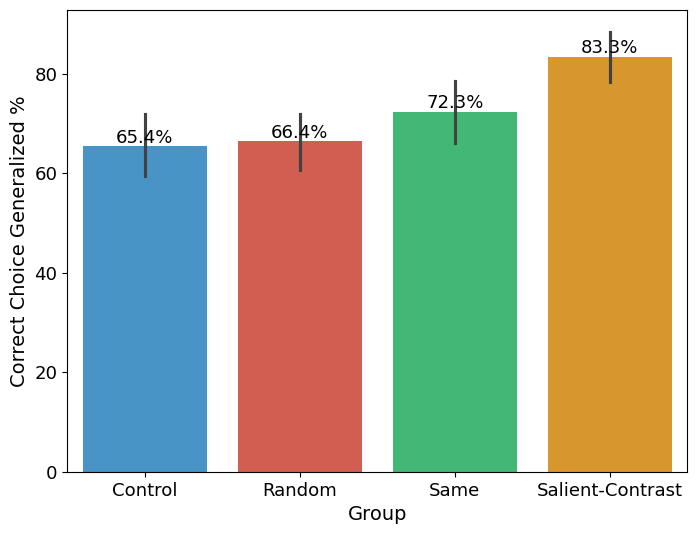

Mann-Whitney U Test Results for Correct Choice (Generalized) by Group
            level_1           level_2        U   p_value
0           Control            Random  29646.0  0.812123
1           Control  Salient-Contrast  20736.0  0.000015
2           Control              Same  20812.5  0.130213
3            Random  Salient-Contrast  22968.0  0.000029
4            Random              Same  23019.0  0.187257
5  Salient-Contrast              Same  22914.0  0.007031


In [13]:
# Plot: Correct Choice (Generalized) by Group
plot_barplot(choice_results, 
                     'group', 
                     'correct_choice_generalized', 
                     palette=colors_palette,
                     y_label='Correct Choice Generalized %',
                     order=group_names,
                     x_val_names=group_names,
                     )

print("Mann-Whitney U Test Results for Correct Choice (Generalized) by Group")
mannwhitneyu_test(choice_results, 'correct_choice_generalized', 'group')

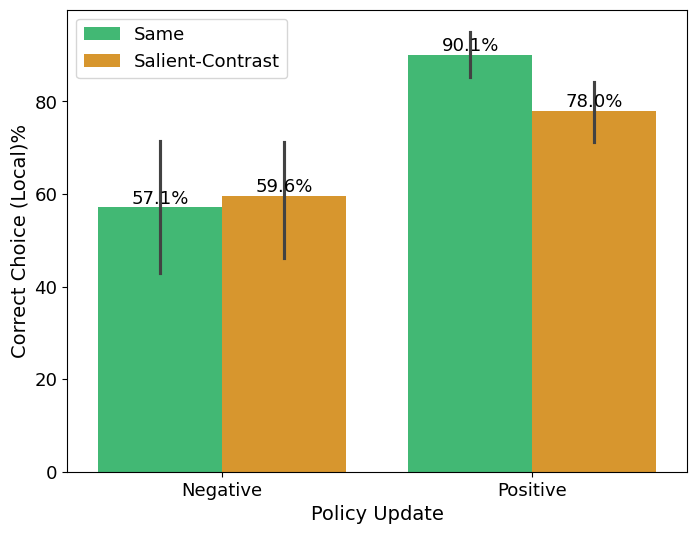

Mann-Whitney U Test Results for Improved from Previous Agent (Local) by Group
            level_1 level_2        U   p_value
0  Salient-Contrast    Same  10236.0  0.004407


In [14]:
# Plot: Correct Choice (Local) by Update Direction Contrast vs Same
plot_df = choice_results[choice_results['group'].isin(group_names[2:4])].copy()
plot_barplot(plot_df,
                     x_col='improved_from_prev_feedback',
                     y_col='correct_choice_feedback',
                     y_label='Correct Choice (Local)%',
                     x_label='Policy Update',
                     x_val_names=['Negative', 'Positive'],
                     hue='group',
                     hue_names=list(plot_df['group'].unique()),
                    palette=colors_palette[2:],

)

print("Mann-Whitney U Test Results for Improved from Previous Agent (Local) by Group")
mannwhitneyu_test(plot_df[plot_df['improved_from_prev_feedback'] == 1], 'correct_choice_feedback', 'group')

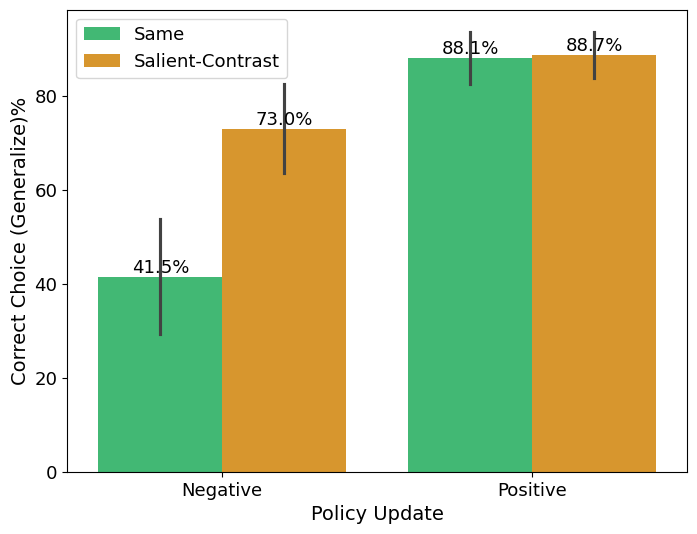

Mann-Whitney U Test Results for Improved from Previous Agent (Generalize) by Group
            level_1 level_2       U   p_value
0  Salient-Contrast    Same  3161.0  0.000188


In [15]:
# Plot: Correct Choice (Generalize) by Update Direction Contrast vs Same
plot_df = choice_results[choice_results['group'].isin(group_names[2:4])].copy()
plot_barplot(plot_df,
                     x_col='improved_from_prev_mean',
                     y_col='correct_choice_generalized',
                     y_label='Correct Choice (Generalize)%',
                     x_label='Policy Update',
                     x_val_names=['Negative', 'Positive'],
                     hue='group',
                     hue_names=list(plot_df['group'].unique()),
                    palette=colors_palette[2:],

)

print("Mann-Whitney U Test Results for Improved from Previous Agent (Generalize) by Group")
mannwhitneyu_test(plot_df[plot_df['improved_from_prev_mean'] == 0], 'correct_choice_generalized', 'group')

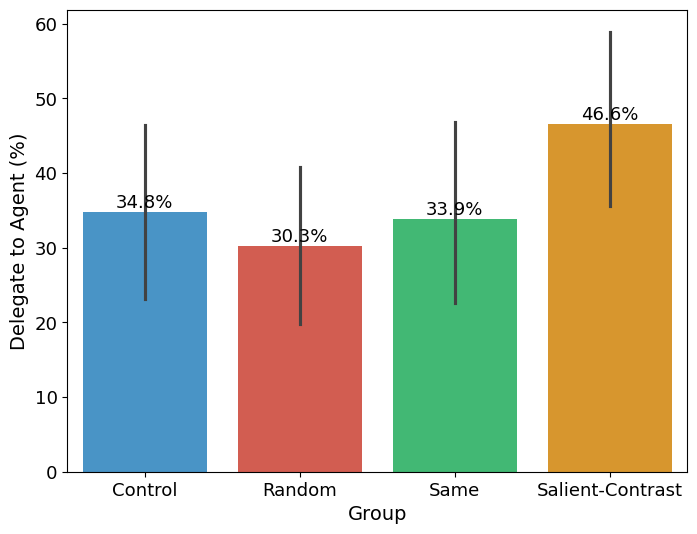

Mann-Whitney U Test Results for Delegate to by Group
            level_1           level_2       U   p_value
0           Control            Random  2740.5  0.719420
1           Control  Salient-Contrast  2221.5  0.077596
2           Control              Same  2158.5  0.544623
3            Random  Salient-Contrast  2321.5  0.020729
4            Random              Same  2271.0  0.327048
5  Salient-Contrast              Same  2550.5  0.932430


In [16]:
# Plot: Delegate to Agent by Group
plot_barplot(
        user_results,
        'group',
        'trust_the_agent',
        y_label='Delegate to Agent (%)',
        x_label='Group',
        x_val_names=group_names,
        estimator=lambda x: np.mean(x) * 100,
        palette=colors_palette,
        errorbar=('ci', 95),
        order=group_names,
        save_path='images/delegate_to_agent_by_group.pdf',
        )

print("Mann-Whitney U Test Results for Delegate to by Group")
mannwhitneyu_test(user_results, 'trust_the_agent', 'group', test_type='less')

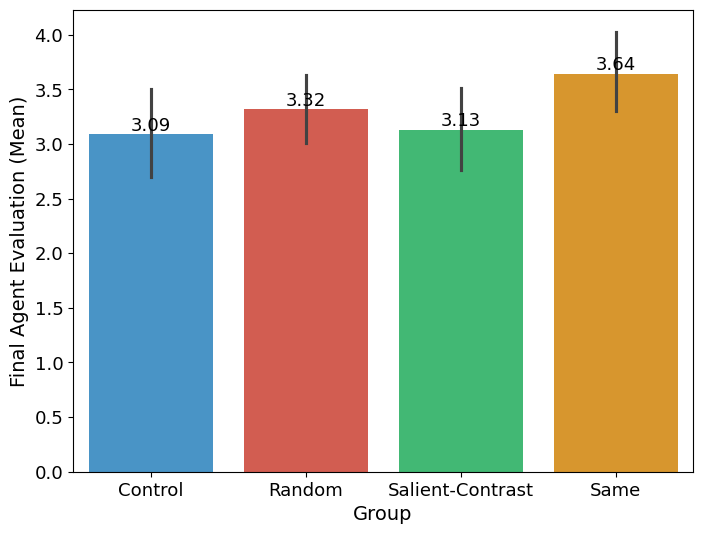

            level_1           level_2       U   p_value
0           Control            Random  2345.5  0.130683
1           Control  Salient-Contrast  1995.5  0.014471
2           Control              Same  2056.5  0.348729
3            Random  Salient-Contrast  2434.0  0.092773
4            Random              Same  2526.0  0.774061
5  Salient-Contrast              Same  2693.0  0.974463


In [17]:
# Plot: Final Agent Evaluation (Mean) by Group

plot_barplot(
        user_results,
        x_col='group',
        y_col='evaluate_final_agent',
        x_label='Group',
        y_label='Final Agent Evaluation (Mean)',
        estimator=lambda x: np.mean(x),
        palette=colors_palette,
        order=group_names,
        bar_label_fmt='%.2f',
)


mannwhitneyu_test(user_results, 'evaluate_final_agent', 'group', test_type='less')


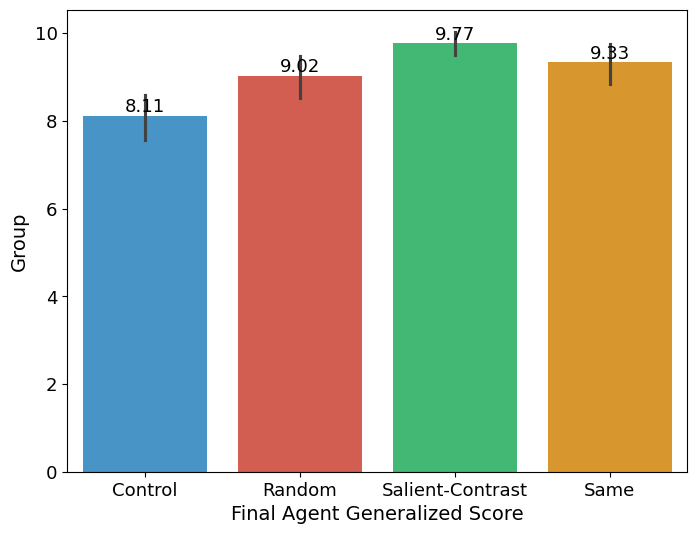

            level_1           level_2       U       p_value
0           Control            Random  1926.0  4.866357e-03
1           Control  Salient-Contrast  1278.5  1.794798e-07
2           Control              Same  1346.5  1.751334e-04
3            Random  Salient-Contrast  2249.5  3.693912e-02
4            Random              Same  2165.5  3.975564e-01
5  Salient-Contrast              Same  2521.5  2.305414e-01


In [18]:
# Plot: Final Agent Generalized Score by Group
plot_df = user_results
plot_barplot(plot_df,
                     'group',
                     'final_agent_mean_score',
                     x_label='Final Agent Generalized Score',
                     y_label='Group',
                     estimator='mean',
                     bar_label_fmt='%.2f',
                     palette=colors_palette,
)


mannwhitneyu_test(plot_df, 'final_agent_mean_score', 'group', test_type='two-sided')

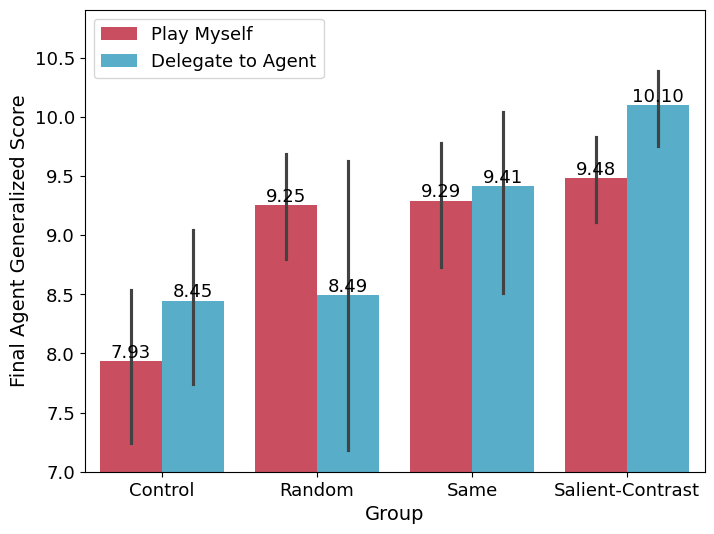

Mann-Whitney_u_test for group  Same
   level_1  level_2      U   p_value
0        0        1  403.5  0.340554
Mann-Whitney_u_test for group  Salient-Contrast
   level_1  level_2      U   p_value
0        0        1  449.0  0.006053
Mann-Whitney_u_test for group  Control
   level_1  level_2      U   p_value
0        0        1  461.0  0.152206
Mann-Whitney_u_test for group  Random
   level_1  level_2      U   p_value
0        0        1  640.0  0.642252


In [19]:
# Plot: Final Agent Generalized Score by Group and Delegate separated
plot_df = user_results
plot_barplot(plot_df,
                     x_col='group',
                     y_col='final_agent_mean_score',
                     x_label='Group',
                     y_label='Final Agent Generalized Score',
                     hue='trust_the_agent',
                     hue_names=['Play Myself','Delegate to Agent'],
                     order=group_names,
                     x_val_names=group_names,
                     bar_label_fmt='%.2f',
                     estimator='mean',
                     palette=["#DC3A52", "#45B6DB"],  # light red and light blue
                     ylim_bottom=7,
                     save_path='images/final_agent_generalized_score_by_group_and_delegate_seperated.pdf'
)


for group in plot_df['group'].unique():
    print('Mann-Whitney_u_test for group ', group)
    mannwhitneyu_test(plot_df[plot_df['group'] == group], 'final_agent_mean_score', 'trust_the_agent', test_type='less')

## Satisfection from the System

ES_combined


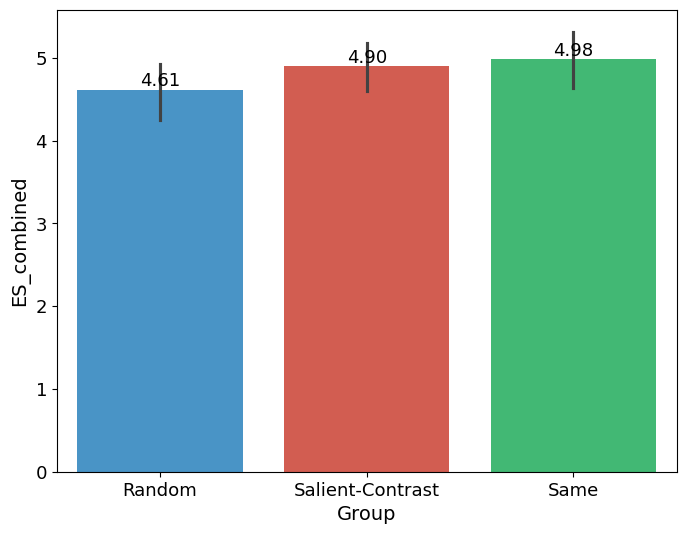

            level_1           level_2       U   p_value
0            Random  Salient-Contrast  2605.5  0.522581
1            Random              Same  2062.0  0.207937
2  Salient-Contrast              Same  2080.0  0.419203


In [20]:
# Plot: Experiment - Satisfection: Satisfection from the System (ES_combined Mean by Group)
ES_questions = ['ES_understandable', # understandable
                'ES_overwhelming', # ovelwhalming
                'ES_feedback_contribution',
                'ES_helpful',
                'ES_combined'
]


i = 4
print(ES_questions[i])

plot_df = user_results[user_results['group'] != 'Control']
plot_barplot(
    df=plot_df,
    y_col=ES_questions[i],
    x_col='group',
    palette=colors_palette,
    x_label='Group',
    y_label=ES_questions[i],
    estimator='mean',
    bar_label_fmt='%.2f',
    order=sorted(list(plot_df['group'].unique()))
)

mannwhitneyu_test(plot_df, ES_questions[i], 'group')

## More ploting

In [21]:
choice_results.columns

Index(['user_id', 'episode', 'group', 'trust_the_agent', 'prev_agent',
       'updated_agent', 'prev_agent_mean_score', 'update_agent_mean_score',
       'prev_agent_feedback_score', 'updated_agent_feedback_score',
       'choice_to_update', 'correct_choice_generalized',
       'correct_choice_feedback', 'choice_time', 'improved_from_prev_feedback',
       'improved_from_prev_mean'],
      dtype='object')

In [29]:
choice_results.groupby('group')['choice_time'].describe()

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
Control,234.0,0.000000,0.000000,0.0,0.0,0.0,0.00,0.0
Random,261.0,32.034483,26.498816,0.0,16.0,25.0,42.00,284.0
Salient-Contrast,220.0,31.636364,20.657338,4.0,18.0,26.0,40.25,133.0
Same,200.0,36.895000,27.964514,3.0,17.0,28.5,47.00,158.0


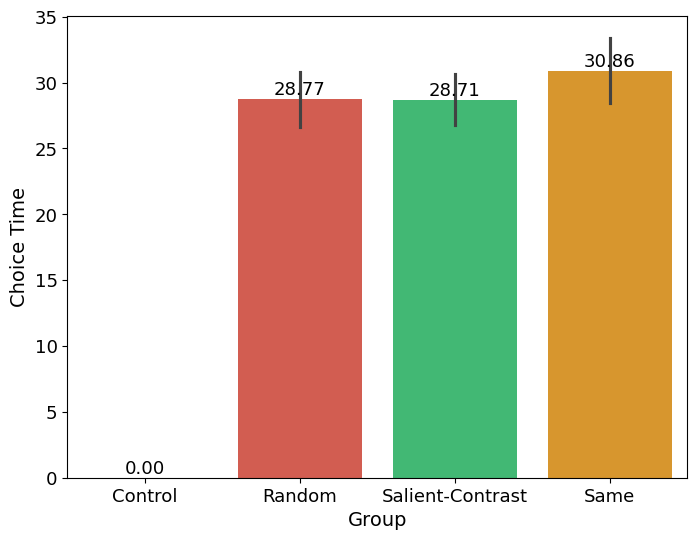

            level_1           level_2        U       p_value
0           Control            Random    117.0  2.298781e-90
1           Control  Salient-Contrast      0.0  1.636643e-86
2           Control              Same      0.0  2.012298e-83
3            Random  Salient-Contrast  25696.5  5.351432e-01
4            Random              Same  21588.0  1.868145e-01
5  Salient-Contrast              Same  18685.5  4.642114e-01


In [22]:
# Plot: Choice time by Group
plot_df = choice_results[choice_results['choice_time'] < 80]
plot_barplot(plot_df,
                     'group',
                     'choice_time',
                     x_label='Group',
                     y_label='Choice Time',
                     estimator='mean',
                     bar_label_fmt='%.2f',
                     palette=colors_palette,
)


mannwhitneyu_test(plot_df, 'choice_time', 'group', test_type='two-sided')

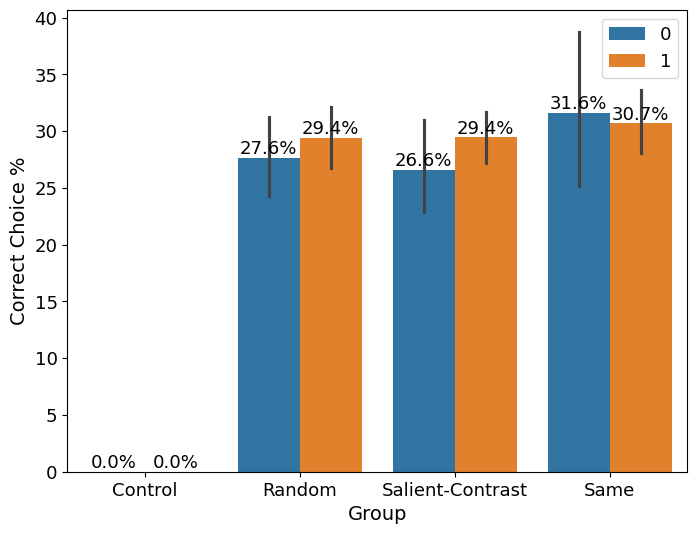

count       mean        std  min  \
group            correct_choice_generalized                                     
Control          0                            81.0   0.000000   0.000000  0.0   
                 1                           153.0   0.000000   0.000000  0.0   
Random           0                            85.0  27.070588  16.263301  5.0   
                 1                           167.0  29.640719  17.704475  0.0   
Salient-Contrast 0                            36.0  28.638889  15.953777  9.0   
                 1                           175.0  28.720000  14.685062  4.0   
Same             0                            51.0  32.450980  17.689900  7.0   
                 1                           134.0  30.261194  17.660512  3.0   

                                              25%   50%    75%   max  
group            correct_choice_generalized                           
Control          0                            0.0   0.0   0.00   0.0  
                 1                            0.0   0.0   0.00   0.0  
Random           0                           13.0  23.0  39.00  69.0  
                 1                           16.0  25.0  39.50  77.0  
Salient-Contrast 0                           17.0  25.5  33.50  74.0  
                 1                           18.0  25.0  39.00  75.0  
Same             0                           18.5  29.0  42.00  72.0  
                 1                           16.0  26.0  39.75  76.0

In [23]:
plot_barplot(plot_df, x_col='group', y_col='choice_time', hue='correct_choice_feedback', estimator='mean')
plot_df.groupby(['group', 'correct_choice_generalized'])['choice_time'].describe()

In [24]:
unique_envs_scores = {'AllColorsLL1_0526': [0, 2.9, 9.3, 4.4, 7.3, 11.9, 5.6, 8.2, 7.6, 3.5, 4.9, 8.0, 6.7, 10.9, 4.1, 8.2, 7.6, 3.7, 4.3, 10.4], 
                      'AllColorsLH_0617': [0, 5.7, 8.9, 13.2, 9.3, 15.1, 11.4, 11.9, 10.8, 6.1, 7.2, 11.0, 9.3, 10.9, 9.8, 7.8, 7.8, 11.0, 9.1, 11.4], 
                      'OnlyBlueLL_0625': [0, 1.7, 7.6, 10.4, 7.7, 9.9, 10.2, 11.6, 3.6, 7.5, 7.8, 6.7, 9.7, 14.1, 4.7, 4.8, 2.7, 8.6, 10.2, 10.4], 
                      'OnlyGreenLL_0429': [0, 2.5, 7.0, 8.3, -11.0, 4.5, -3.4, 5.6, 7.5, 2.6, -5.4, 8.4, 0.8, 7.3, 4.4, -0.5, -0.5, -8.6, 5.7, 2.4], 
                      'OnlyBlueLH_0706': [0, 3.8, 7.6, 11.1, 7.7, 12.8, 11.4, 11.6, 12.8, 9.5, 7.8, 6.5, 9.7, 11.5, 7.4, 7.6, 7.6, 11.4, 8.6, 10.4], 
                      'NoRedLH1_0612': [0, 9.1, 10.0, 14.4, 9.5, 15.1, 12.9, 12.8, 14.7, 9.5, 11.2, 9.9, 9.7, 13.4, 10.2, 9.3, 9.1, 11.4, 12.2, 13.0]}

## New plots

In [10]:
raw_choice_results['group'] = raw_choice_results['similarity_level'].map({0: 'Control', 1: 'Same', 2: 'Contrast', 3: 'Random'})

In [12]:
raw_choice_results.columns

Index(['user_id', 'episode', 'similarity_level', 'Trust_the_agent',
       'feedback_score', 'prev_agent', 'update_agent', 'prev_agent_mean_score',
       'update_agent_mean_score', 'prev_agent_last_score',
       'update_agent_last_score', 'choice', 'good_choice', 'good_choice_last',
       'choice_time', 'examples_shown', 'feedback_board_index',
       'demo_board_index', 'good_choice_demo', 'improved_from_base',
       'improved_from_base_last', 'improved_from_prev_last',
       'improved_from_prev_mean', 'final_agent', 'final_agent_score', 'group'],
      dtype='object')

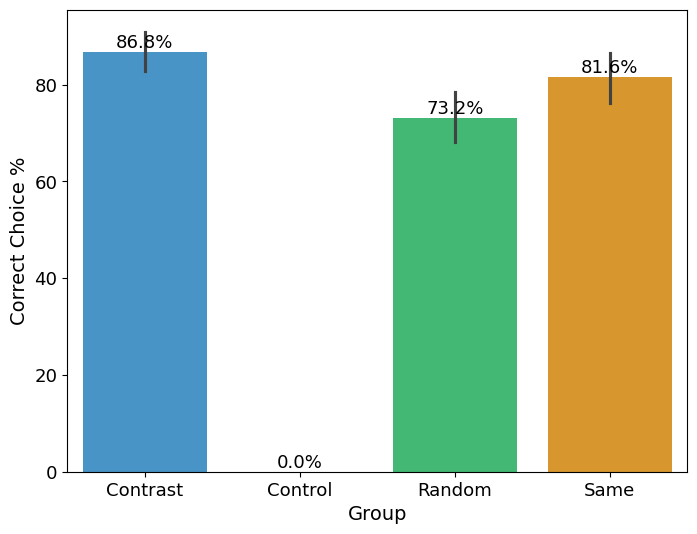

    level_1  level_2        U   p_value
0  Contrast  Control      NaN       NaN
1  Contrast   Random  32625.5  0.000232
2  Contrast     Same  23265.5  0.141357
3   Control   Random      NaN       NaN
4   Control     Same      NaN       NaN
5    Random     Same  24024.0  0.033831


In [15]:
plot_barplot(raw_choice_results, x_col='group', y_col='good_choice_demo', palette=colors_palette)
mannwhitneyu_test(raw_choice_results, 'good_choice_demo', 'group', test_type='two-sided')

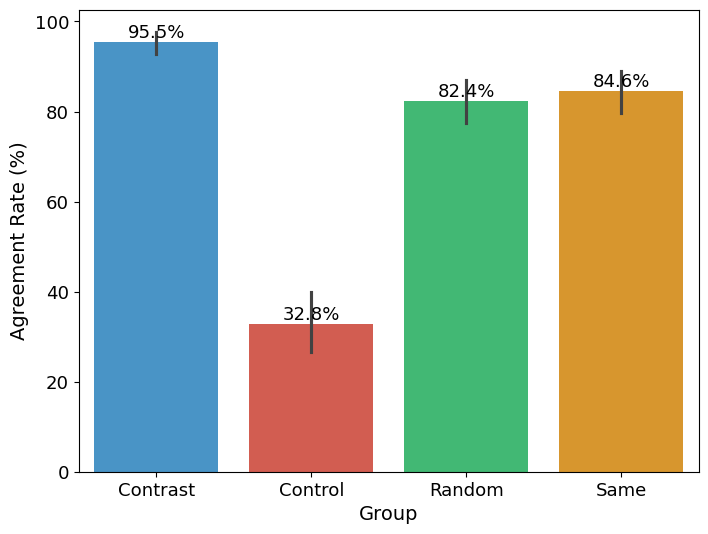


Mann-Whitney U Test for Agreement Rate between Groups:
    level_1  level_2        U       p_value
0  Contrast  Control  34885.0  4.098330e-41
1  Contrast   Random  32465.0  8.577758e-06
2  Contrast     Same  24515.0  1.734828e-04
3   Control   Random  12837.0  7.311046e-27
4   Control     Same   9454.5  1.331656e-25
5    Random     Same  25653.0  5.298120e-01

--- Agreement Counts by Group ---
Control: 64/195 (32.8%)
Random: 215/261 (82.4%)
Same: 170/201 (84.6%)
Salient-Contrast: 0/0 (nan%)


In [22]:
# Calculate agreement rate: how often good_choice equals good_choice_demo by group
plot_df = raw_choice_results.dropna(subset=['good_choice', 'good_choice_demo']).copy()

# Create agreement indicator
plot_df['choice_agreement'] = (plot_df['good_choice'] == plot_df['good_choice_demo']).astype(int)

# Plot agreement rate
plot_barplot(
    plot_df,
    x_col='group',
    y_col='choice_agreement',
    x_label='Group',
    y_label='Agreement Rate (%)',
    palette=colors_palette,
    # order=group_names,
    # x_val_names=group_names,
)

# Statistical test
print("\nMann-Whitney U Test for Agreement Rate between Groups:")
mannwhitneyu_test(plot_df, 'choice_agreement', 'group', test_type='two-sided')

# Show counts per group
print("\n--- Agreement Counts by Group ---")
for group in group_names:
    grp = plot_df[plot_df['group'] == group]
    agree = grp['choice_agreement'].sum()
    total = len(grp)
    print(f"{group}: {agree}/{total} ({100*agree/total:.1f}%)")